# Data prep + Model A (baseline)

My part: cleaning the AID dataset, EDA, train/val/test split, data pipeline, and the baseline CNN (Model A). Models B/C/D and the API are the rest of the team's job.

Classes used (10 out of 30): Forest, Desert, Beach, River, Mountain, DenseResidential, Industrial, Airport, Stadium, Farmland


In [1]:
import os
import glob
import hashlib
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

REPO_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
RAW_DIR = os.path.join(REPO_ROOT, "data", "raw", "AID")
SPLITS_DIR = os.path.join(REPO_ROOT, "data", "splits")
RESULTS_DIR = os.path.join(REPO_ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
ARTIFACTS_DIR = os.path.join(REPO_ROOT, "artifacts")

for d in (SPLITS_DIR, RESULTS_DIR, FIGURES_DIR, ARTIFACTS_DIR):
    os.makedirs(d, exist_ok=True)

TARGET_CLASSES = [
    "Forest", "Desert", "Beach", "River", "Mountain",
    "DenseResidential", "Industrial", "Airport", "Stadium", "Farmland",
]
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

print("Repo root:", REPO_ROOT)
print("Raw data dir:", RAW_DIR)


Repo root: C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification
Raw data dir: C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification\data\raw\AID


## 1. Keep only the 10 classes
Removes the other 20 folders from data/raw/AID.

In [2]:
all_class_dirs = [d for d in os.listdir(RAW_DIR) if os.path.isdir(os.path.join(RAW_DIR, d))]
removed = []
for d in all_class_dirs:
    if d not in TARGET_CLASSES:
        import shutil
        shutil.rmtree(os.path.join(RAW_DIR, d))
        removed.append(d)

if removed:
    print(f"Removed {len(removed)} non-target class folders:", removed)
else:
    print("Only target classes present, nothing to remove.")

remaining = sorted(os.listdir(RAW_DIR))
assert set(remaining) == set(TARGET_CLASSES), f"Mismatch: {remaining}"
print("Confirmed: exactly the 10 target classes are present.")


Only target classes present, nothing to remove.
Confirmed: exactly the 10 target classes are present.


## 2. EDA

Per-class image counts:
label
River               410
DenseResidential    410
Beach               400
Industrial          390
Farmland            370
Airport             360
Mountain            340
Desert              300
Stadium             290
Forest              250
Name: count, dtype: int64

Balance ratio (largest/smallest) = 410 / 250 = 1.640
Balance constraint satisfied (<= 2x).


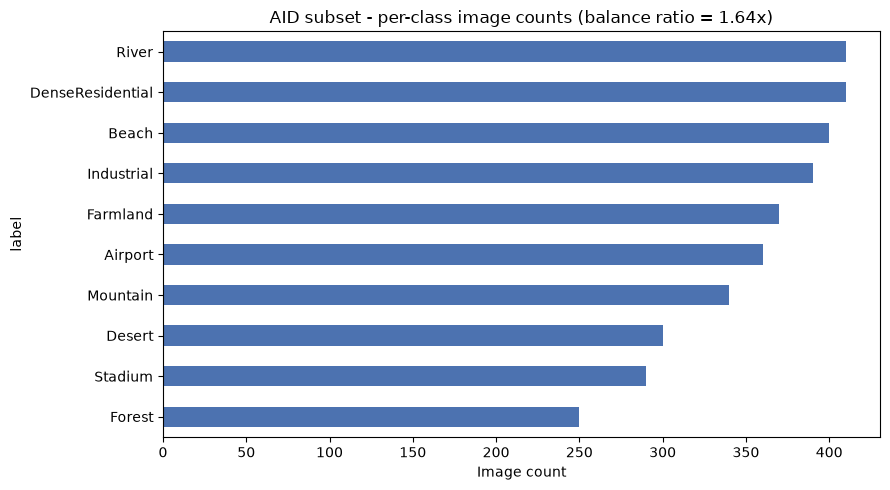

In [3]:
def build_manifest(raw_dir=RAW_DIR, classes=TARGET_CLASSES):
    rows = []
    for label in classes:
        class_dir = os.path.join(raw_dir, label)
        for fname in os.listdir(class_dir):
            rows.append({"filepath": os.path.join(class_dir, fname), "label": label})
    return pd.DataFrame(rows)

manifest = build_manifest()
counts = manifest["label"].value_counts()
print("Per-class image counts:")
print(counts)

balance_ratio = counts.max() / counts.min()
print(f"\nBalance ratio (largest/smallest) = {counts.max()} / {counts.min()} = {balance_ratio:.3f}")
assert balance_ratio <= 2.0
print("Balance constraint satisfied (<= 2x).")

fig, ax = plt.subplots(figsize=(9, 5))
counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Image count")
ax.set_title(f"AID subset - per-class image counts (balance ratio = {balance_ratio:.2f}x)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_balance.png"), dpi=120)
plt.show()


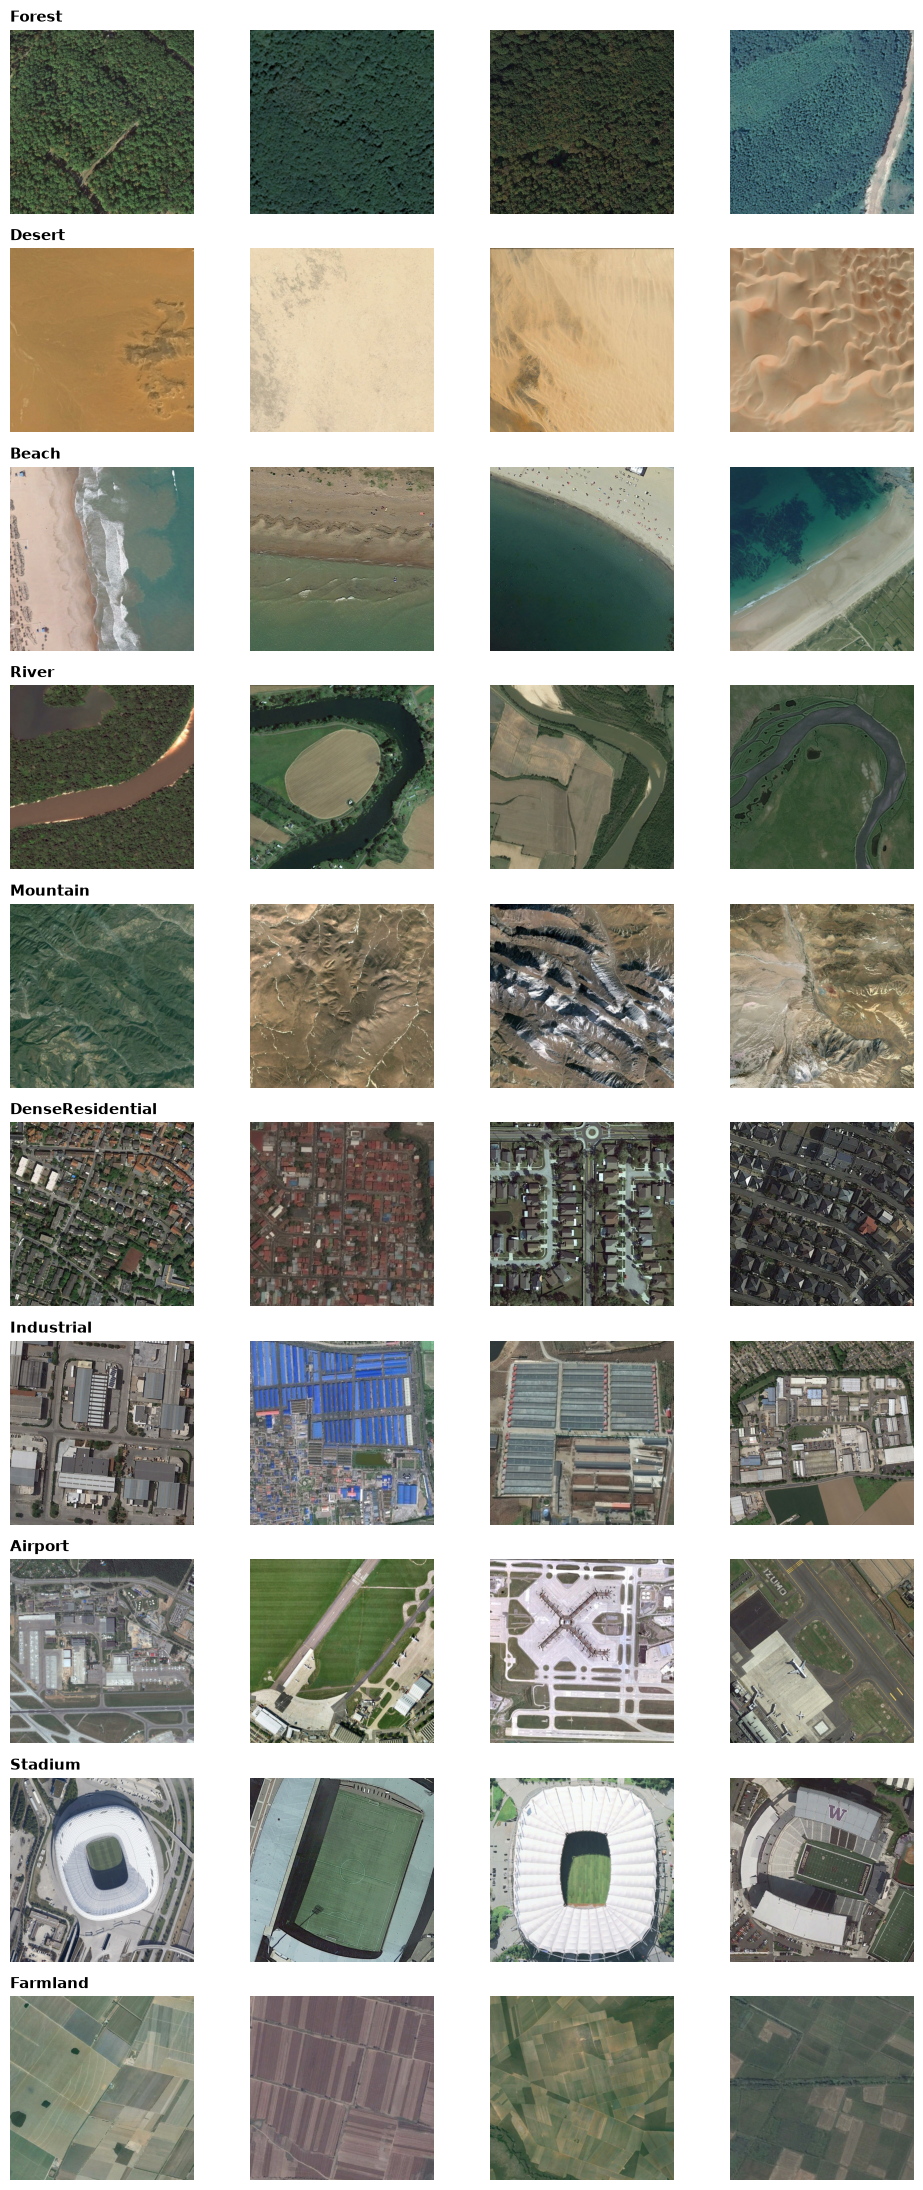

In [4]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(TARGET_CLASSES), 4, figsize=(10, 2.2 * len(TARGET_CLASSES)))
for i, label in enumerate(TARGET_CLASSES):
    class_files = manifest.loc[manifest["label"] == label, "filepath"].tolist()
    sample = rng.choice(class_files, size=4, replace=False)
    for j, fp in enumerate(sample):
        img = Image.open(fp)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(label, fontsize=10)
    axes[i, 0].set_title(label, loc="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_grid.png"), dpi=120)
plt.show()


In [5]:
def audit_images(df):
    widths, heights, formats, corrupted = [], [], [], []
    for path in df["filepath"]:
        try:
            with Image.open(path) as img:
                img.verify()
            with Image.open(path) as img:
                w, h = img.size
                fmt = img.format
            widths.append(w); heights.append(h); formats.append(fmt); corrupted.append(False)
        except Exception:
            widths.append(None); heights.append(None); formats.append(None); corrupted.append(True)
    out = df.copy()
    out["width"], out["height"], out["format"], out["corrupted"] = widths, heights, formats, corrupted
    return out

audited = audit_images(manifest)
n_corrupt = int(audited["corrupted"].sum())
print("Corrupted / unreadable files:", n_corrupt)

dim_mismatch = audited[(audited["width"] != 600) | (audited["height"] != 600)]
print("Files not exactly 600x600:", len(dim_mismatch))

print("\nContent format counts (by actual file signature, not extension):")
print(audited["format"].value_counts(dropna=False))

fmt_mismatch = audited[audited["format"] != "JPEG"]
if len(fmt_mismatch):
    print(f"\nNote: {len(fmt_mismatch)} files are named .jpg but are actually "
          f"{fmt_mismatch['format'].unique().tolist()} internally -- "
          f"all in class(es): {fmt_mismatch['label'].unique().tolist()}. "
          "The loading pipeline below uses tf.io.decode_image (format-agnostic) "
          "instead of decode_jpeg specifically to handle this safely.")


Corrupted / unreadable files: 0
Files not exactly 600x600: 0

Content format counts (by actual file signature, not extension):
format
JPEG    3439
PNG       81
Name: count, dtype: int64

Note: 81 files are named .jpg but are actually ['PNG'] internally -- all in class(es): ['DenseResidential']. The loading pipeline below uses tf.io.decode_image (format-agnostic) instead of decode_jpeg specifically to handle this safely.


## 3. Cleaning
Drop corrupted files and exact duplicates.

In [6]:
def find_duplicates(df):
    hashes = {}
    is_dup = []
    for path in df["filepath"]:
        with open(path, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        is_dup.append(h in hashes)
        hashes.setdefault(h, path)
    return pd.Series(is_dup, index=df.index)

clean = audited[~audited["corrupted"]].copy()
dup_mask = find_duplicates(clean)
n_dupes = int(dup_mask.sum())
clean = clean[~dup_mask].reset_index(drop=True)

print(f"Dropped {n_corrupt} corrupted + {n_dupes} duplicate files.")
print("Final clean dataset size:", len(clean))
print(clean["label"].value_counts())

clean_ratio = clean["label"].value_counts().max() / clean["label"].value_counts().min()
print(f"Balance ratio after cleaning: {clean_ratio:.3f}")

clean["filepath"] = clean["filepath"].apply(lambda p: os.path.relpath(p, REPO_ROOT).replace("\\", "/"))
clean[["filepath", "label"]].to_csv(os.path.join(SPLITS_DIR, "clean_manifest.csv"), index=False)


Dropped 0 corrupted + 0 duplicate files.
Final clean dataset size: 3520
label
River               410
DenseResidential    410
Beach               400
Industrial          390
Farmland            370
Airport             360
Mountain            340
Desert              300
Stadium             290
Forest              250
Name: count, dtype: int64
Balance ratio after cleaning: 1.640


## 4. Train/val/test split (70/15/15, seed=42)

In [7]:
train_df, temp_df = train_test_split(
    clean, test_size=0.30, stratify=clean["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)
train_df = train_df.assign(split="train")
val_df = val_df.assign(split="val")
test_df = test_df.assign(split="test")

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

all_paths = pd.concat([train_df["filepath"], val_df["filepath"], test_df["filepath"]])
assert all_paths.is_unique
print("No leakage: every image appears in exactly one split.")

cols = ["filepath", "label", "split"]
train_df[cols].to_csv(os.path.join(SPLITS_DIR, "train.csv"), index=False)
val_df[cols].to_csv(os.path.join(SPLITS_DIR, "val.csv"), index=False)
test_df[cols].to_csv(os.path.join(SPLITS_DIR, "test.csv"), index=False)
print("Saved train.csv / val.csv / test.csv to", SPLITS_DIR)


Train: 2464 | Val: 528 | Test: 528
No leakage: every image appears in exactly one split.
Saved train.csv / val.csv / test.csv to C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification\data\splits


## 5. Data pipeline
Resize, batch, shuffle (train only), prefetch. No augmentation, that's Model C's job.

In [8]:
CLASS_TO_IDX = {c: i for i, c in enumerate(TARGET_CLASSES)}

def make_dataset(csv_path, img_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False, seed=SEED):
    df = pd.read_csv(csv_path)
    filepaths = [os.path.join(REPO_ROOT, p) for p in df["filepath"]]
    labels = [CLASS_TO_IDX[l] for l in df["label"]]

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    def _load(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, img_size)
        return img, label

    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=seed)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(os.path.join(SPLITS_DIR, "train.csv"), shuffle=True)
val_ds = make_dataset(os.path.join(SPLITS_DIR, "val.csv"), shuffle=False)
test_ds = make_dataset(os.path.join(SPLITS_DIR, "test.csv"), shuffle=False)

for imgs, labels in train_ds.take(1):
    print("Batch image shape:", imgs.shape, "| dtype:", imgs.dtype)
    print("Batch label shape:", labels.shape)


Batch image shape: (32, 160, 160, 3) | dtype: <dtype: 'float32'>
Batch label shape: (32,)


## 6. Model A - baseline CNN
Simple version: 2 conv blocks, no BatchNorm/Dropout/Augmentation.

In [9]:
def build_cnn(num_classes: int, config: dict) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(160, 160, 3))
    x = tf.keras.layers.Rescaling(1.0 / 255)(inputs)
    x = tf.keras.layers.RandomFlip("horizontal")(x)
    for filters in config["filters"]:
        x = tf.keras.layers.Conv2D(
            filters, kernel_size=config["kernel_size"], padding="same",
            use_bias=not config["batch_norm"],
        )(x)
        if config["batch_norm"]:
            x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(config["dropout"])(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name=config["name"])

model_a_config = {
    "name": "model_a_baseline",
    "filters": [32, 64],
    "kernel_size": 3,
    "batch_norm": False,
    "dropout": 0.1,
}

model_a = build_cnn(num_classes=len(TARGET_CLASSES), config=model_a_config)
model_a.summary()

n_params = model_a.count_params()
print(f"\nTotal parameters: {n_params:,}")


Model: "model_a_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,042 (78.29 KB)

 Trainable params: 20,042 (78.29 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 20,042


In [10]:
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS = 15
start = time.time()
history = model_a.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, verbose=2)
train_time_sec = time.time() - start
print(f"\nTraining time: {train_time_sec:.1f} sec for {EPOCHS} epochs")


Epoch 1/15


C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 - 25s - 330ms/step - accuracy: 0.2208 - loss: 2.1658 - val_accuracy: 0.2689 - val_loss: 1.9868


Epoch 2/15


77/77 - 23s - 293ms/step - accuracy: 0.3442 - loss: 1.8305 - val_accuracy: 0.3731 - val_loss: 1.7405


...

Epoch 14/15


77/77 - 28s - 360ms/step - accuracy: 0.5771 - loss: 1.1894 - val_accuracy: 0.5492 - val_loss: 1.2727


Epoch 15/15


77/77 - 28s - 358ms/step - accuracy: 0.5808 - loss: 1.1656 - val_accuracy: 0.5663 - val_loss: 1.2066



Training time: 393.7 sec for 15 epochs


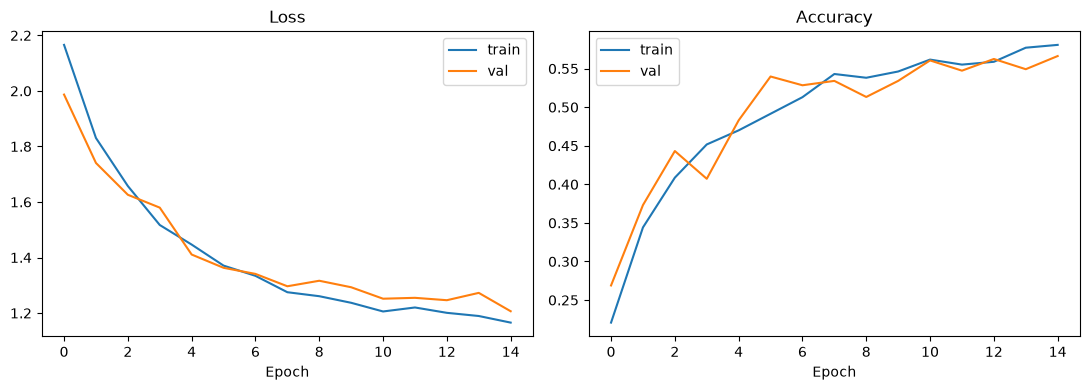

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_a_curves.png"), dpi=120)
plt.show()


Model A test accuracy: 0.5928 | test loss: 1.1283


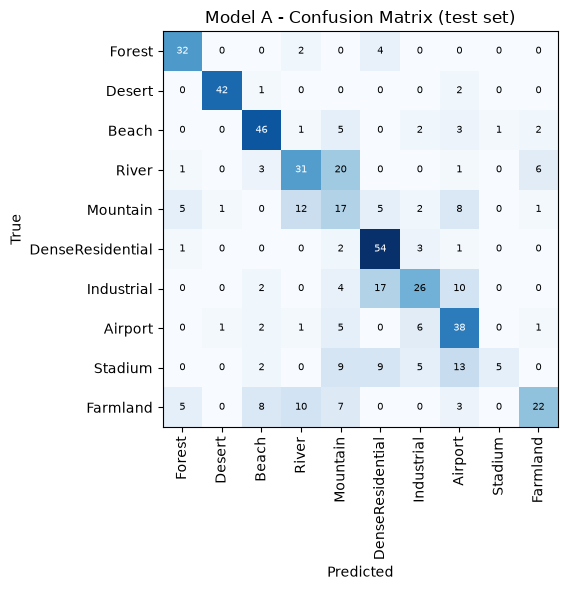

                  precision    recall  f1-score   support

          Forest       0.73      0.84      0.78        38
          Desert       0.95      0.93      0.94        45
           Beach       0.72      0.77      0.74        60
           River       0.54      0.50      0.52        62
        Mountain       0.25      0.33      0.28        51
DenseResidential       0.61      0.89      0.72        61
      Industrial       0.59      0.44      0.50        59
         Airport       0.48      0.70      0.57        54
         Stadium       0.83      0.12      0.20        43
        Farmland       0.69      0.40      0.51        55

        accuracy                           0.59       528
       macro avg       0.64      0.59      0.58       528
    weighted avg       0.63      0.59      0.58       528



In [12]:
test_loss, test_acc = model_a.evaluate(test_ds, verbose=0)
print(f"Model A test accuracy: {test_acc:.4f} | test loss: {test_loss:.4f}")

y_true, y_pred = [], []
for imgs, labels in test_ds:
    probs = model_a.predict(imgs, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(TARGET_CLASSES))); ax.set_xticklabels(TARGET_CLASSES, rotation=90)
ax.set_yticks(range(len(TARGET_CLASSES))); ax.set_yticklabels(TARGET_CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Model A - Confusion Matrix (test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_a_confusion_matrix.png"), dpi=120)
plt.show()

print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))


In [13]:
model_a.save(os.path.join(ARTIFACTS_DIR, "model_a_baseline.keras"))

history_out = {
    "model": "model_a_baseline",
    "config": model_a_config,
    "epochs": EPOCHS,
    "train_time_sec": train_time_sec,
    "n_params": int(n_params),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "history": {k: [float(v) for v in vals] for k, vals in history.history.items()},
}
with open(os.path.join(RESULTS_DIR, "model_a_history.json"), "w") as f:
    json.dump(history_out, f, indent=2)

print("Saved model to", os.path.join(ARTIFACTS_DIR, "model_a_baseline.keras"))
print("Saved training history to", os.path.join(RESULTS_DIR, "model_a_history.json"))


Saved model to C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification\artifacts\model_a_baseline.keras
Saved training history to C:\Users\leuna\OneDrive\سطح المكتب\AID-Scene_Classification\results\model_a_history.json


## Recap

- 10 classes kept, other 20 removed from data/raw/AID
- EDA + plots saved in results/figures
- corrupted/duplicate check done, clean list saved in data/splits/clean_manifest.csv
- 70/15/15 split saved as csv, checked for leakage
- data pipeline function in this notebook (resize/batch/shuffle/prefetch)
- Model A trained and saved to artifacts/model_a_baseline.keras, history in results/model_a_history.json
